# Plotting Vector Data

This notebook demonstrates how to plot various vector data formats using `gplately`. We'll cover the following formats:

- `CSV files`: Point data with latitude and longitude (e.g. fossil or sample locations)

- `XY files`: Custom, manually defined point coordinates

- `Shapefiles (.shp)`: Static polylines or polygons (e.g. coastlines)

- `GPML files`: Plate tectonic features from GPlates (e.g. reconstructed coastlines, plate boundaries, topologies)

### Setup

Let’s start by importing the required packages.

In [2]:
# Ensure you have the required packages installed:
# Run `pip install gplately pygplates cartopy geopandas matplotlib pandas numpy` if not already installed.
import gplately
from plate_model_manager import PlateModelManager
import pygplates
import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Now, let's use gplately's `PlateModelManager` to create a plate reconstruction model based on the Müller et al. (2019) global plate model, [“A Global Plate Model Including Lithospheric Deformation Along Major Rifts and Orogens Since the Triassic”](https://www.earthbyte.org/muller-et-al-2019-deforming-plate-reconstruction-and-seafloor-age-grids-tectonics/).

> `NOTE:` You can also load a plate model through local files on your system!

We then extract individual layers from the model:

- Coastlines: for reconstructing ancient shorelines.

- ContinentalPolygons: for plotting continental outlines.

- COBs (Continent-Ocean Boundaries): useful for defining the transition between land and oceanic crust.

Finally, we create a `PlotTopologies object (gplot)`, which simplifies visualizing reconstructed features like plate boundaries, continents, and COBs at any geological time.

In [3]:
pm_manager = PlateModelManager()

# Load the Muller 2019 plate model 
muller2019_model = pm_manager.get_model("Muller2019", data_dir="plate-model-repo")

# This object will allow us to reconstruct the plate boundaries at different times
model = gplately.PlateReconstruction(
    muller2019_model.get_rotation_model(),
    muller2019_model.get_topologies(),
    muller2019_model.get_static_polygons()
)

# Coastlines, Continental polygons and COBs
coastlines = muller2019_model.get_layer('Coastlines')
continents = muller2019_model.get_layer('ContinentalPolygons')
COBs = muller2019_model.get_layer('COBs')

# Create PlotTopologies object
gplot = gplately.PlotTopologies(model, coastlines=coastlines, continents=continents, COBs=COBs)

time_ma = 100  # Ma (Million years ago)

### Format 1: Plotting Points from CSV

In this method, we will learn how to plot points from a CSV file. In this example, we import data from the [PBDB]("https://paleobiodb.org/classic/displayDownloadGenerator") using the data url straight into `pandas`. Alternatively, we can download the csv file from their website and import that. The data is of the distribution of Jurassic Foraminifera (a type of microscopic organism) over time.

We're using the `Cartopy` library to plot geological features (like continents, ridges, and subduction zones). We also use GPlates to plot coastlines and other geological data at 100 Ma and place points representing the locations of Foraminifera on the map.

> `NOTE:` When importing CSV files, it is generally easier if the first row contains column names, as this helps with automatically identifying the data fields. However, if the CSV file doesn't include headers or includes extra metadata, libraries like Pandas allow you to skip these header rows when importing the data.


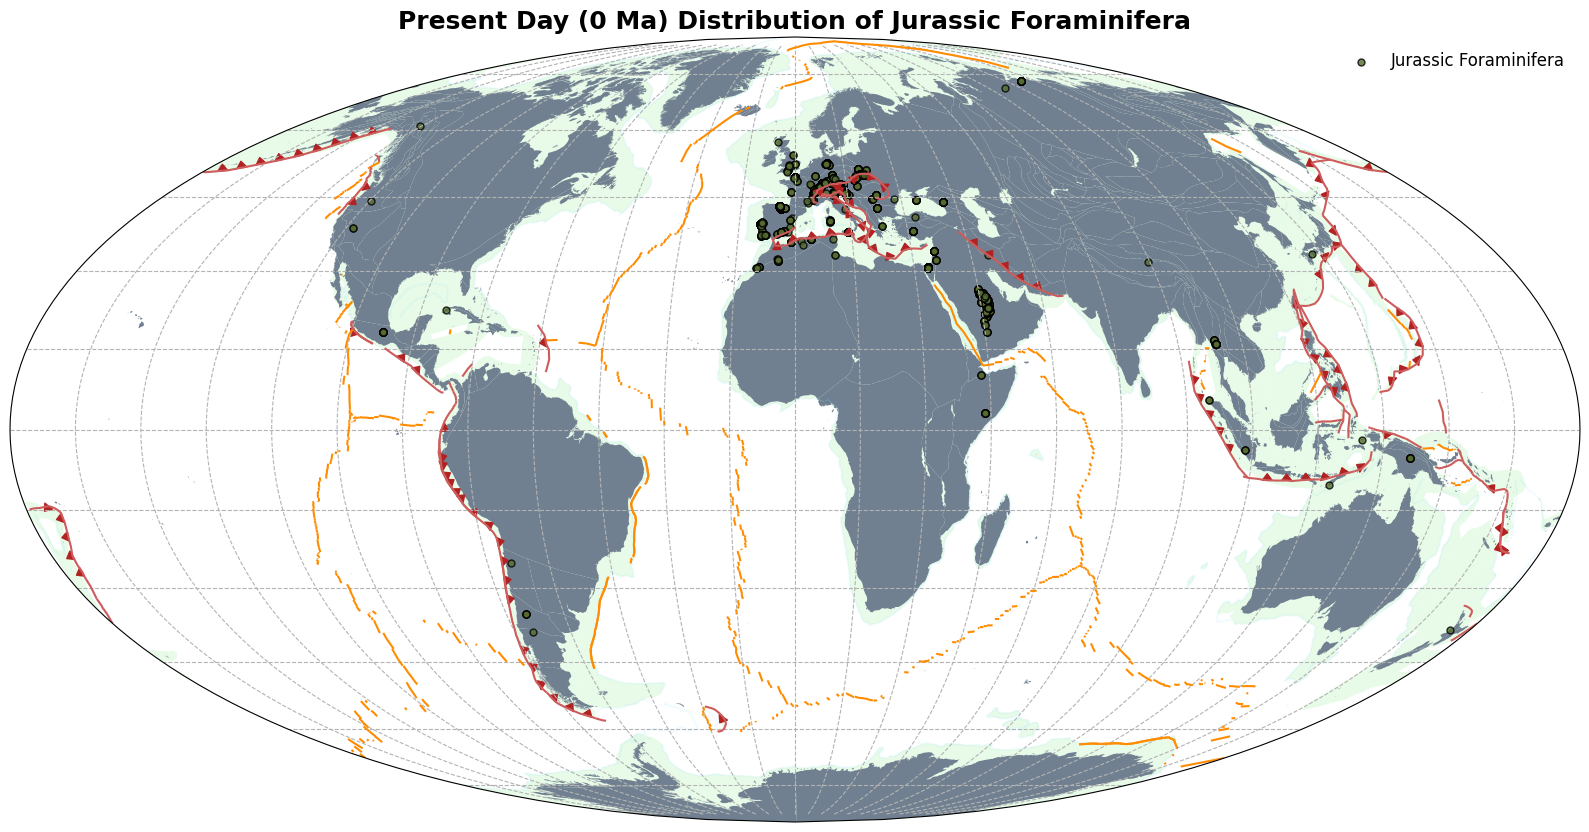

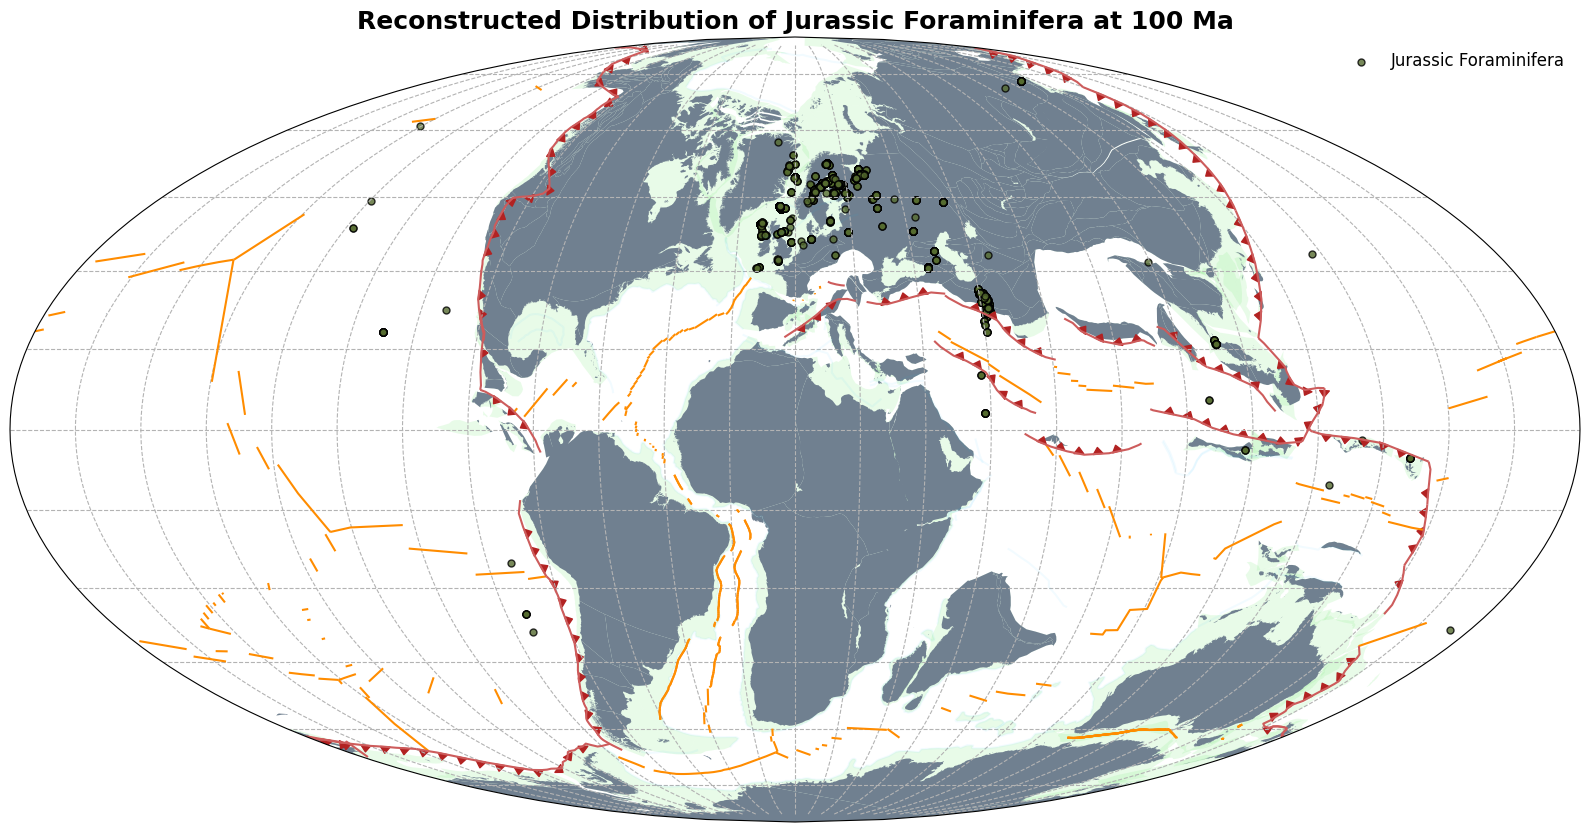

In [ ]:
# ---- Load the CSV point data ----
# Replace this URL with the actual URL of your CSV file
pbdb_data_url = 'https://paleobiodb.org/data1.2/occs/list.csv?datainfo&rowcount&base_name=Foraminifera&interval=Jurassic&show=coords,env'
points = pd.read_csv(pbdb_data_url, sep=',', skiprows=18)

# The CSV contains columns for latitude and longitude
longitudes = points['lng']
latitudes = points['lat']


# --- PLOT 1: Present Day (0 Ma) ---
# Plot for Present day (0 Ma)
plt.figure(figsize=(16, 12), dpi=100)
ax = plt.subplot(111, projection=ccrs.Mollweide(central_longitude=0))
ax.set_global()
ax.gridlines(color='0.7', linestyle='--', xlocs=np.arange(-180, 180, 15), ylocs=np.arange(-90, 90, 15))
ax.set_title("Present Day (0 Ma) Distribution of Jurassic Foraminifera", fontsize=18, fontweight='bold')

# Plot shapefile features
gplot.time = 0  # Set time to present day
gplot.plot_continent_ocean_boundaries(ax, color='deepskyblue', alpha=0.05)
gplot.plot_continents(ax, facecolor='lightgreen', alpha=0.2)
gplot.plot_coastlines(ax, color='slategray')
gplot.plot_ridges(ax, color='darkorange')
gplot.plot_trenches(ax, color='indianred')
gplot.plot_subduction_teeth(ax, color='firebrick')

# Scatter plot of the points
ax.scatter(longitudes, latitudes, color='#556B2F', transform=ccrs.PlateCarree(), label='Jurassic Foraminifera', s=25, edgecolor='black', alpha=0.8)
ax.legend(frameon=False, loc='upper right', fontsize=12)
plt.tight_layout()

# Show present day plot
plt.show()


# ---- PLOT 2: Reconstructed to 100 Ma ----
plt.figure(figsize=(16, 12), dpi=100)
ax = plt.subplot(111, projection=ccrs.Mollweide(central_longitude=0))
ax.set_global()
ax.gridlines(color='0.7', linestyle='--', xlocs=np.arange(-180, 180, 15), ylocs=np.arange(-90, 90, 15))
ax.set_title("Reconstructed Distribution of Jurassic Foraminifera at 100 Ma", fontsize=18, fontweight='bold')

# Plot shapefile features
gplot.time = time_ma  # Set time to 100 Ma (from setup above)
gplot.plot_continent_ocean_boundaries(ax, color='deepskyblue', alpha=0.05)
gplot.plot_continents(ax, facecolor='lightgreen', alpha=0.2)
gplot.plot_coastlines(ax, color='slategray')
gplot.plot_ridges(ax, color='darkorange')
gplot.plot_trenches(ax, color='indianred')
gplot.plot_subduction_teeth(ax, color='firebrick')

# Scatter plot of the points for 100 Ma (reconstructed positions)
ax.scatter(longitudes, latitudes, color='#556B2F', transform=ccrs.PlateCarree(), label='Jurassic Foraminifera', s=25, edgecolor='black', alpha=0.8)
ax.legend(frameon=False, loc='upper right', fontsize=12)
plt.tight_layout()

# Show reconstructed plot for 100 Ma
plt.show()

### Format 2: Plotting Points from XY Data 

This code shows how to plot XY data (i.e. longitude-latitude data). We do this by plotting several major capital cities on a world map: both as they are today, and as they might have been located 100 million years ago (based on plate tectonic movement).

- A list of well-known cities (like Sydney, London, Tokyo) is created, with each city’s current latitude and longitude.

- Each city is matched to the tectonic plate it sits on (e.g., Sydney → Australian Plate). These plate IDs are necessary to tell the model which chunk of Earth’s crust the city belongs to, so it knows how to move it back in time.

- Each city is turned into a pyGPlates point feature, so it can be reconstructed using the plate motion model.

- We then plot the present day map and the global map reconstructed to 100 Ma.

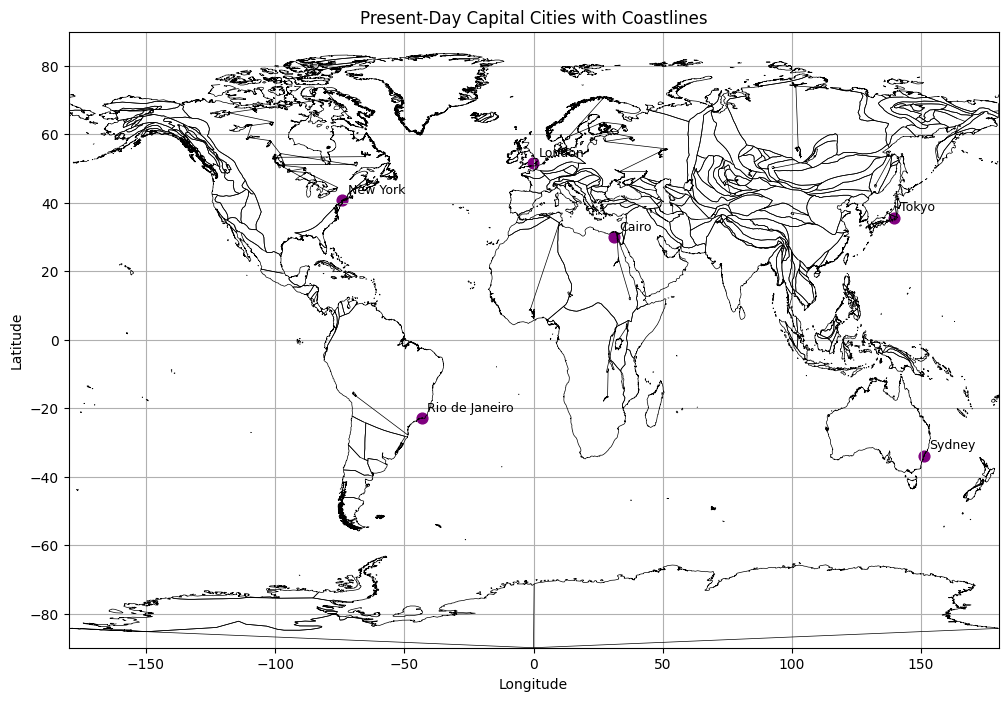

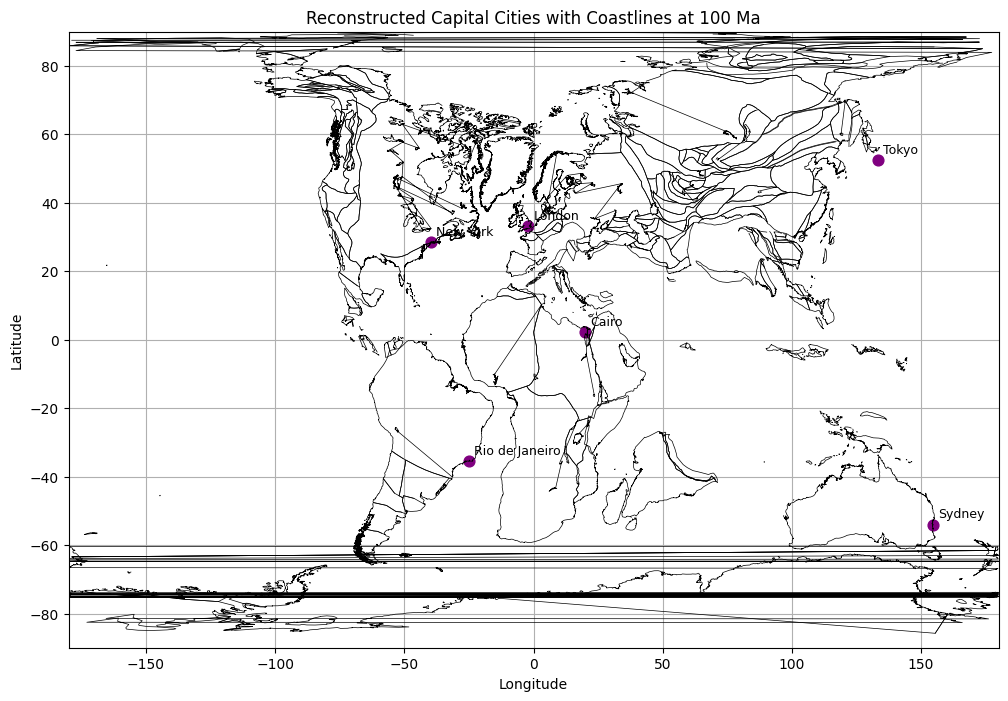

In [ ]:
# --- Get present-day coastlines from model ---
coastlines = muller2019_model.get_layer('Coastlines')

# --- Define XY data (longitude, latitude, city name) ---
# You can replace this with your own data or XY file!
cities = [
    {'name': 'Sydney', 'lon': 151.2093, 'lat': -33.8688},
    {'name': 'London', 'lon': -0.1278, 'lat': 51.5074},
    {'name': 'Tokyo', 'lon': 139.6917, 'lat': 35.6895},
    {'name': 'Cairo', 'lon': 31.2357, 'lat': 30.0444},
    {'name': 'Rio de Janeiro', 'lon': -43.1729, 'lat': -22.9068},
    {'name': 'New York', 'lon': -74.0060, 'lat': 40.7128}
]

df_cities = pd.DataFrame(cities)

# Convert city data to pygplates features with plate IDs
point_features = []

for _, row in df_cities.iterrows():
    point = pygplates.PointOnSphere(row['lat'], row['lon'])
    feature = pygplates.Feature()
    feature.set_geometry(point)
    
    # Assign plate IDs based on approximate continental locations
    if row['name'] == 'Sydney':
        plate_id = 801  # Australia
    elif row['name'] == 'London':
        plate_id = 301  # Eurasia
    elif row['name'] == 'Tokyo':
        plate_id = 301  # Eurasia
    elif row['name'] == 'Cairo':
        plate_id = 701  # Africa
    elif row['name'] == 'Rio de Janeiro':
        plate_id = 201  # South America
    elif row['name'] == 'New York':
        plate_id = 101  # North America
    else:
        plate_id = 0    # Default/anchor plate
    
    feature.set_reconstruction_plate_id(plate_id)
    point_features.append(feature)

# --- Plot settings ---
figsize = (12, 8)
xlim = (-180, 180)
ylim = (-90, 90)
dot_size = 60
dot_color = 'purple'
coastline_color = 'black'
coastline_width = 0.5

# Function to plot coastlines at given time
def plot_coastlines(ax, time):
    reconstructed_coastlines = model.reconstruct(coastlines, to_time=time)
    for feature in reconstructed_coastlines:
        geom = feature.get_reconstructed_geometry()
        if geom and hasattr(geom, 'to_lat_lon_array'):
            coords = geom.to_lat_lon_array()
            lons = coords[:, 1]
            lats = coords[:, 0]
            ax.plot(lons, lats, color=coastline_color, linewidth=coastline_width)

# --- PLOT 1: Present Day (0 Ma) ---
fig, ax = plt.subplots(figsize=figsize)

# Plot present-day coastlines
plot_coastlines(ax, time=0)

# Plot cities on top
ax.scatter(df_cities['lon'], df_cities['lat'], color=dot_color, s=dot_size)
for _, row in df_cities.iterrows():
    ax.text(row['lon'] + 2, row['lat'] + 2, row['name'], fontsize=9)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Present-Day Capital Cities with Coastlines")
ax.grid(True)
plt.show()

# --- PLOT 2: Reconstructed to 100 Ma ---
fig, ax = plt.subplots(figsize=figsize)

# Plot reconstructed coastlines
plot_coastlines(ax, time=time_ma)

# Reconstruct cities back to 100 Ma using the correct model
reconstructed_points = model.reconstruct(
    point_features,
    to_time=time_ma,    # Reconstruct to 100 Ma
    anchor_plate_id=model.anchor_plate_id
)

# Extract reconstructed positions
recon_lons = []
recon_lats = []

for feature in reconstructed_points:
    geom = feature.get_reconstructed_geometry()
    if geom:
        lat, lon = geom.to_lat_lon()
        recon_lons.append(lon)
        recon_lats.append(lat)

# Plot reconstructed cities
if recon_lons and recon_lats:  # Check if we have reconstructed positions
    ax.scatter(recon_lons, recon_lats, color=dot_color, s=dot_size)
    for i, row in df_cities.iterrows():
        if i < len(recon_lons):  # Make sure we have a corresponding reconstructed position
            ax.text(recon_lons[i] + 2, recon_lats[i] + 2, row['name'], fontsize=9)
else:
    print("Warning: No reconstructed positions found. Check plate IDs and model.")

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Reconstructed Capital Cities with Coastlines at {time_ma} Ma")
ax.grid(True)
plt.show()

### Format 3: Plotting from a Shapefile (.shp)

Here, we plot a `.shp` file that contains simplified present-day coastlines. These are static i.e. they don’t account for plate movement over time. By combining shapefiles with a plate motion model, you can "rewind" Earth’s surface and visualize how coastlines, landmasses, and ocean basins looked in the deep past.

This code shows how to visualize coastlines in two ways:

1. As they appear today (from a static shapefile):

    - Loads the .shp file using geopandas (gpd).

    - Plots the coastlines on a global map in blue, showing the modern configuration of continents.

2. As they looked 100 million years ago, using a plate tectonic reconstruction model:

    - Loads the same shapefile into pyGPlates as a FeatureCollection.

    - Reconstructs the coastlines back to 100 million years ago, using the plate motion model.

    - Plots these reconstructed coastlines. This shows how the continents were arranged at that time in Earth’s history.

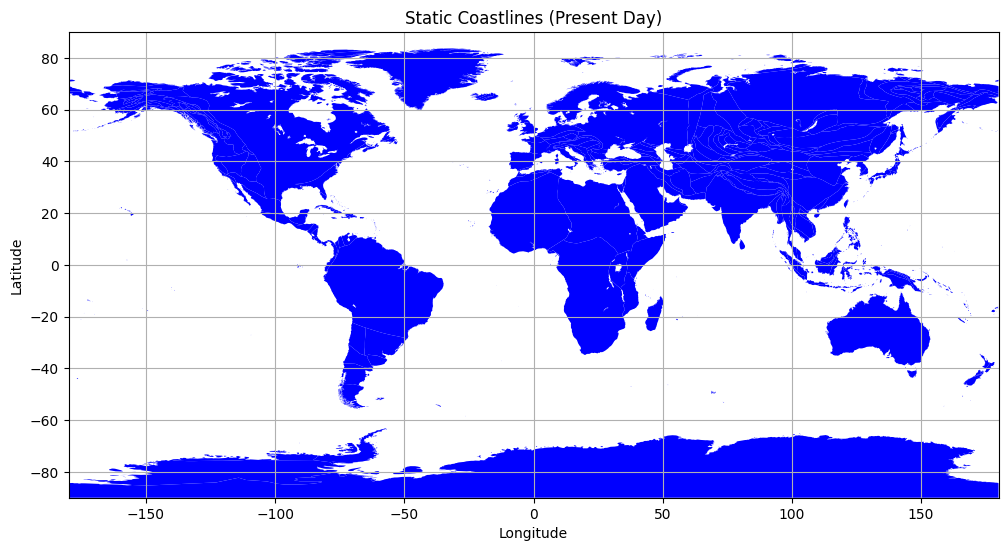

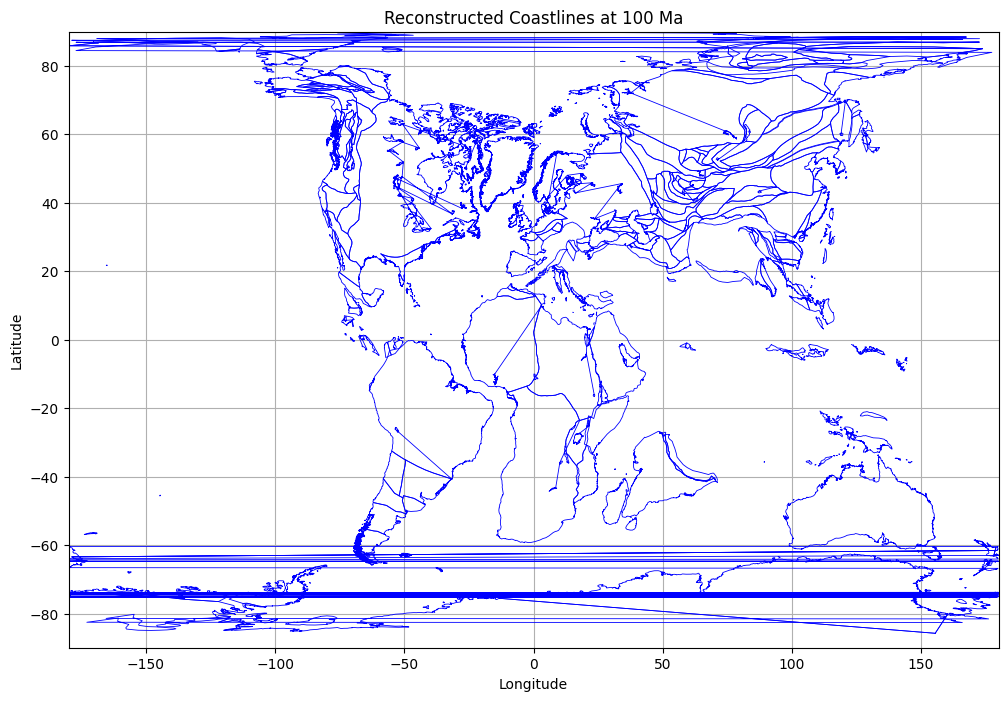

In [ ]:
# --- Common plot settings ---
figsize = (12, 8)
line_color = 'blue'
line_width = 0.6
xlim = (-180, 180)
ylim = (-90, 90)

# ---- Load the .shp file ----
# Update with your shapefile path
shapefile_path = "../../data/Muller_etal_2019_PlateMotionModel_v2.0_Tectonics/StaticGeometries/Coastlines/Global_coastlines_2019_v1_low_res.shp"

# --- PLOT 1: Present Day (0 Ma) ---
coastline_data = gpd.read_file(shapefile_path)

fig, ax = plt.subplots(figsize=figsize)
coastline_data.plot(ax=ax, color=line_color, linewidth=line_width)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Static Coastlines (Present Day)')
ax.grid(True)
plt.show()

# ---- PLOT 2: Reconstructed to 100 Ma ----
# Load the shapefile into a pygplates FeatureCollection
coastline_features = pygplates.FeatureCollection(shapefile_path)

# Reconstruct the features to 100 Ma
reconstructed = model.reconstruct(
    coastline_features,
    to_time=time_ma,    # Time = 100 Ma (from setup above)
    anchor_plate_id=model.anchor_plate_id
)

fig, ax = plt.subplots(figsize=figsize)

# Loop through the reconstructed features and plot them
for feature in reconstructed:
    geom = feature.get_reconstructed_geometry()
    if geom and hasattr(geom, 'to_lat_lon_array'):
        coords = geom.to_lat_lon_array()
        lons = coords[:, 1]
        lats = coords[:, 0]
        ax.plot(lons, lats, color=line_color, linewidth=line_width)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Reconstructed Coastlines at {time_ma} Ma')
ax.grid(True)
plt.show()

### Format 4: Plotting from a GPML file

In this section, we visualize tectonic plate features from a GPML file: a file format used to describe geological and tectonic data in the GPlates ecosystem. GPML stands for **GPlates Markup Language** and contains detailed feature geometries, such as deforming regions, topological boundaries, and other geological structures.

We're using the file `Australia_Antarctica_Mesh_Topologies_2019_v2.gpml`
which defines the mesh topologies (i.e., internal plate boundaries and deformation zones) between Australia and Antarctica.

- Load the GPML file: We convert it into a FeatureCollection, a format PyGPlates can work with.

- Plot Present-Day Features: Here, coastlines from the present are shown as black outlines and topology lines from the GPML file are plotted in dark green.

- Plot Reconstructed Features (100 Ma): We "reconstruct" both the coastlines and topologies back to 100 million years ago using a plate motion model.

This lets us see what the plate boundaries and continents likely looked like at that time!

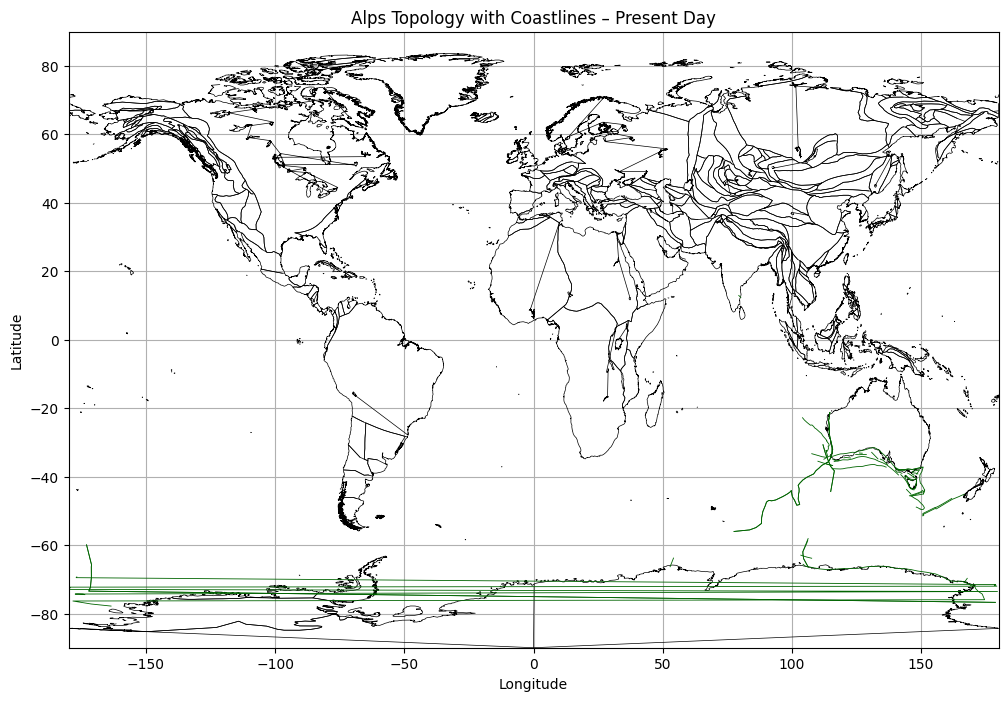

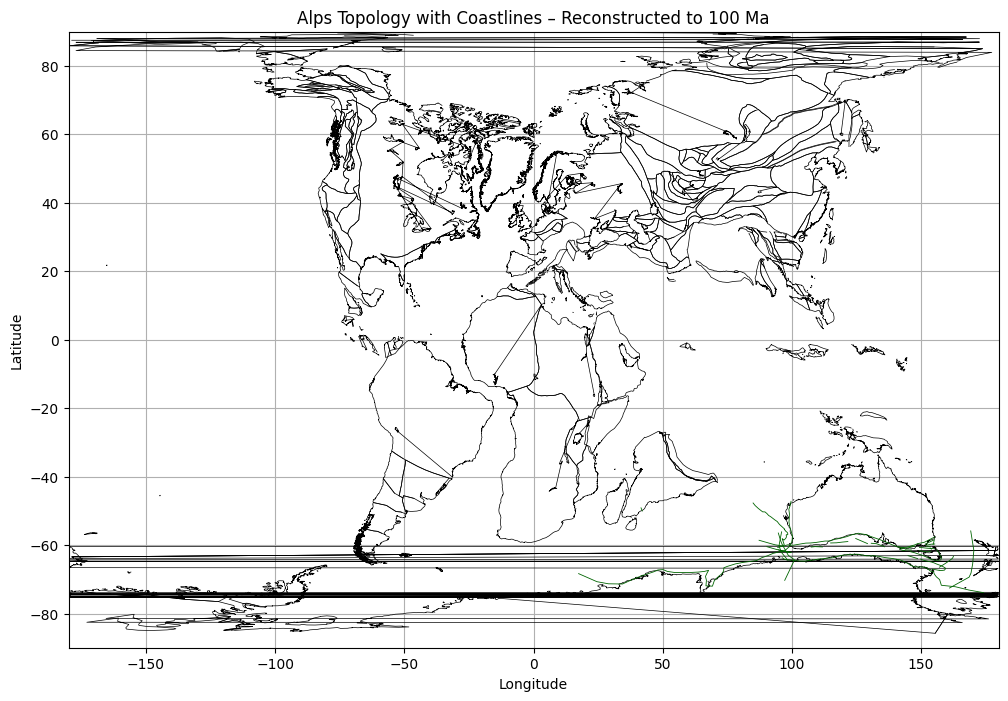

In [ ]:
# --- Path to your GPML topology file ---
gpml_path = "../../data/Muller_etal_2019_PlateMotionModel_v2.0_Tectonics/Australia_Antarctica_Mesh_Topologies_2019_v2.gpml"

# --- Common plot settings ---
figsize = (12, 8)
topology_color = 'darkgreen'
coastline_color = 'black'
line_width = 0.6
xlim = (-180, 180)
ylim = (-90, 90)

# --- Load the GPML file as a FeatureCollection ---
topology_features = pygplates.FeatureCollection(gpml_path)

# --- Get coastlines from model ---
coastlines = muller2019_model.get_layer('Coastlines')

# --- Function to plot coastlines at any time ---
def plot_coastlines(ax, time):
    reconstructed_coastlines = model.reconstruct(coastlines, to_time=time)
    for feature in reconstructed_coastlines:
        geom = feature.get_reconstructed_geometry()
        if geom and hasattr(geom, 'to_lat_lon_array'):
            coords = geom.to_lat_lon_array()
            lons = coords[:, 1]
            lats = coords[:, 0]
            ax.plot(lons, lats, color=coastline_color, linewidth=0.5)

# --- PLOT 1: Present Day (0 Ma) ---
fig, ax = plt.subplots(figsize=figsize)

# Plot coastlines (present day)
plot_coastlines(ax, time=0)

# Plot topology features (present day, no reconstruction)
for feature in topology_features:
    geometry = feature.get_geometry()
    if geometry and hasattr(geometry, 'to_lat_lon_array'):
        coords = geometry.to_lat_lon_array()
        lons = coords[:, 1]
        lats = coords[:, 0]
        ax.plot(lons, lats, color=topology_color, linewidth=line_width)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Alps Topology with Coastlines – Present Day")
ax.grid(True)
plt.show()

# --- PLOT 2: Reconstructed to 100 Ma ---
fig, ax = plt.subplots(figsize=figsize)

# Plot reconstructed coastlines
plot_coastlines(ax, time=time_ma)

# Reconstruct topology features to 100 Ma
reconstructed_topology = model.reconstruct(
    topology_features,
    to_time=time_ma,   # Time = 100 Ma (from setup above)
    anchor_plate_id=model.anchor_plate_id
)

# Plot reconstructed topology
for feature in reconstructed_topology:
    geometry = feature.get_reconstructed_geometry()
    if geometry and hasattr(geometry, 'to_lat_lon_array'):
        coords = geometry.to_lat_lon_array()
        lons = coords[:, 1]
        lats = coords[:, 0]
        ax.plot(lons, lats, color=topology_color, linewidth=line_width)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Alps Topology with Coastlines – Reconstructed to {time_ma} Ma")
ax.grid(True)
plt.show()